# 11 — Macro characterization & contamination-steered Track A

**Spec:** `track-a-macro-steering` — task 4.1 (Requirements 2.1-2.4, 3.3, 5.1-5.3, 6.1-6.4).

This append-only playbook reuses the **finished steering engine**
(`macro_framework/steering.py`, already on `main`) and the **measured** memorization
calibrator from task 3.2. It does **not** modify notebooks 01-10, any existing module,
or any existing `data/` artifact; every output is written under a **new** filename.

It does four things:

1. **PIT macro characterization (R2).** For each of the 72 monthly rebalances
   (2019-01 -> 2024-12) it calls `steering.characterize(...)` on the macro panel sliced
   **strictly before** the rebalance date, producing a deterministic regime label + the
   as-of per-series z-summary, and persists them as a steering-signal artifact.
2. **Macro + contamination-steered Track A variant (R3).** It **replays the recorded v1
   agent views** (from `data/track_a_agent_log.json` — no OpenRouter re-run) and drives
   the steering engine's `make_steered_weight_fn` through the unchanged
   `build_walk_forward_targets`. Steering's only effect is **confidence/inclusion
   shaping** from the macro regime and the measured `p_memorized`; the v1 decisions
   themselves are identical.
3. **Scoring + distribution (R1.2 reuse, R5.2).** Each rebalance's directional prompt
   (`render_directional`) is scored on the **separate logprob-bearing NIM path** with the
   task-3.2 calibrated scorer; `p_memorized` is attached to the steered decision log and
   summarized via `score_distribution_report`.
4. **Head-to-head (R5).** A `"Track A (steered)"` row is added to
   `mf.head_to_head_report(pfs, targets)` alongside Baseline / Track A / Track B
   **without editing `evaluation.py`**, plus the `p_memorized` distribution.

> **Success definition (R5.3) — non-predictive.** Success is **lower-or-equal measured
> contamination with non-degraded head-to-head metrics**, *not* improved forecast
> accuracy. The anonymized, dateless PIT macro prompts are expected to score uniformly
> **low** `p_memorized` (task 3.2 smoke: ~0.05; nb11 mean over 72 prompts ≈ 0.17), so steering applies a gentle
> `(1 - p_memorized)` discount and the 0.8 exclusion gate rarely/never fires — the
> desired low-contamination regime, not a failure.

> **Calibration validity (R1.7).** Task 3.2 calibrated
> `meta/llama-4-maverick-17b-128e-instruct` @ cutoff `2024-08-01` to
> `holdout_auc ≈ 0.913` (re-calibrated in-cell; task 3.2 reported 0.924), `is_weak = False`. Steering is therefore **enabled**; if the
> calibrator were weak this notebook would degrade the steered variant to plain Track A
> and report the weakness.


## 1. Setup

In [1]:
import json
import sys
import warnings
from datetime import date
from pathlib import Path

warnings.filterwarnings("ignore")
REPO = Path.cwd().parent
sys.path.insert(0, str(REPO))

import numpy as np
import pandas as pd
from dotenv import load_dotenv

import macro_framework as mf
from macro_framework import steering

load_dotenv(REPO / ".env")
pd.set_option("display.width", 200)

DATA = REPO / "data"
INIT_CASH = 10_000.0
SIM_START = "2019-01-01"
SIM_END = "2024-12-31"
LOOKBACK_DAYS = 756
TILT = 0.30  # nb09 final blend = 0.7*HRP + 0.3*BL

# Task-3.2 calibrated model + cutoff (research.md 2026-06-26 "Task 3.2 result").
NIM_MODEL = "meta/llama-4-maverick-17b-128e-instruct"
CUTOFF = date(2024, 8, 1)
SLUG = NIM_MODEL.replace("/", "_")

spec = pd.read_parquet(DATA / "portfolio_ssr_top_per_category.parquet")
SYMBOLS = spec["symbol"].tolist()
asset_map = mf.AssetMap.default()
PANEL_Z_COLS = ["cpi_yoy_z", "t10y2y_z", "hy_oas_z"]
print("SYMBOLS:", SYMBOLS)
print("NIM model:", NIM_MODEL, "| cutoff:", CUTOFF.isoformat())


SYMBOLS: ['SWDA.L', 'XLK', 'IAU', 'BIL']
NIM model: meta/llama-4-maverick-17b-128e-instruct | cutoff: 2024-08-01


## 2. Reuse the existing macro panel + prices (R2.3, R6.1)

The macro panel is read from the committed `data/macro_panel_monthly.parquet`
(**reuse, not regenerate** — R2.3). The price DB (`mf.get_prices`, Postgres
`etf_prices`) is not provisioned in this run, so daily prices are fetched once from a
public source (`yfinance`, auto-adjusted total return) **inside this additive notebook**
— no module is edited. All four variants in the head-to-head are reconstructed from the
**same** price set, so the comparison is internally consistent (apples-to-apples). The
load-bearing comparison is **Track A (steered) vs Track A**, and both share identical
prices, so steering's effect is isolated.

In [2]:
macro_panel = pd.read_parquet(DATA / "macro_panel_monthly.parquet")
macro_panel.index = pd.DatetimeIndex(macro_panel.index)
print("macro panel:", macro_panel.shape, "|", macro_panel.index.min().date(), "->", macro_panel.index.max().date())

# Daily prices (DB unavailable here -> public source; additive, no module change).
def _fetch_prices() -> pd.DataFrame:
    import time
    import yfinance as yf
    want = SYMBOLS + ["SPY"]
    last_exc = None
    for attempt in range(6):
        try:
            raw = yf.download(want, start="2014-01-01", end=SIM_END,
                              auto_adjust=True, progress=False, threads=False)
            close = raw["Close"] if ("Close" in raw.columns.get_level_values(0)) else raw
            close = close[want].copy()
            close.index = pd.DatetimeIndex(close.index)
            if close[SYMBOLS].dropna(how="all").shape[0] > 1000:
                return close
        except Exception as exc:  # noqa: BLE001
            last_exc = exc
        time.sleep(8)
    raise RuntimeError(f"price fetch failed after retries: {last_exc!r}")

prices = _fetch_prices()
print("prices:", prices.shape, "|", prices.index.min().date(), "->", prices.index.max().date())
print(prices[SYMBOLS].notna().sum().to_dict())


macro panel: (196, 6) | 2010-01-31 -> 2026-04-30


prices: (2828, 5) | 2014-01-02 -> 2024-12-30
{'SWDA.L': 2778, 'XLK': 2767, 'IAU': 2767, 'BIL': 2767}


## 3. Replay agent — same v1 decisions, no OpenRouter re-run (efficiency + fidelity)

`data/track_a_agent_log.json` already holds the 72 recorded v1 views / reasoning /
macro_state. The **replay agent** returns the recorded `MacroView` list for a rebalance's
macro_state (keyed on the rounded z-scores, exactly as the agent's own cache key rounds
them) and delegates `views_to_bl` to a real `mf.LlmMacroAgent` (a pure, network-free
method that only needs the `AssetMap`). The steered variant therefore uses the **identical
v1 decisions**; steering only shapes confidence.

In [3]:
agent_log = json.loads((DATA / "track_a_agent_log.json").read_text())
recorded_views = {pd.Timestamp(k): v for k, v in agent_log["views"].items()}
recorded_state = {pd.Timestamp(k): v for k, v in agent_log["macro_state"].items()}
recorded_reasoning = {pd.Timestamp(k): v for k, v in agent_log["reasoning"].items()}
print(f"recorded rebalances in v1 agent log: {len(recorded_views)}")


def _round_key(state: dict) -> tuple:
    # Mirror LlmMacroAgent.views_for_state rounding (z-scores to 2dp) so a
    # PIT-reconstructed macro_state resolves to the recorded views.
    return tuple(round(float(state[c]), 2) for c in PANEL_Z_COLS)


_views_by_round = {_round_key(s): recorded_views[d] for d, s in recorded_state.items()}


class ReplayMacroAgent:
    '''Returns the recorded v1 views for a macro_state; delegates views_to_bl.

    No network: views_for_state is a lookup over the committed agent log, and
    views_to_bl is the unchanged, pure LlmMacroAgent method (AssetMap math only).
    '''

    def __init__(self, asset_map: mf.AssetMap) -> None:
        # A real agent instance purely for its unchanged views_to_bl (no LLM call).
        self._bl_agent = mf.LlmMacroAgent(asset_map=asset_map)

    def views_for_state(self, macro_state, asset_snapshot):
        raw = _views_by_round.get(_round_key(macro_state))
        if raw is None:
            return [], ""  # unseen state -> no views (combine falls back to base)
        views = [mf.MacroView(**v) for v in raw]
        return views, ""

    def views_to_bl(self, views, real_symbols):
        return self._bl_agent.views_to_bl(views, real_symbols)


replay_agent = ReplayMacroAgent(asset_map)

# Sanity: every recorded macro_state resolves back to its own views.
_resolved = sum(1 for s in recorded_state.values() if _views_by_round.get(_round_key(s)) is not None)
print(f"replay lookup resolves {_resolved}/{len(recorded_state)} recorded states")


recorded rebalances in v1 agent log: 72
replay lookup resolves 72/72 recorded states


## 4. Calibrated scorer — reuse the task-3.2 model/cutoff (R1.2, R1.7)

The scorer is rebuilt from the **on-disk** FMP corpora (`data/calibration/{is_memorized,
oos_control}.jsonl`, gitignored but present; regenerable via
`scripts/calibrate_nim_scorer.py`) read through `steering._read_corpus_jsonl`, then
`MemoryGuardedScorer.calibrate(...)` on the **separate NIM inference path**. We confirm
`is_weak is False` (task 3.2: AUC 0.924). If it were weak, steering would fall back to
unsteered and we would report that.

In [4]:
import os

from recall_guard import MemoryGuardedScorer
from macro_framework.steering import _read_corpus_jsonl

nvidia_key = (os.environ.get("NVIDIA_API_KEY") or "").strip()
if not nvidia_key:
    raise RuntimeError("NVIDIA_API_KEY not set in .env — required for the separate NIM scoring path")

CAL_DIR = DATA / "calibration"
is_path = CAL_DIR / "is_memorized.jsonl"
oos_path = CAL_DIR / "oos_control.jsonl"
if not (is_path.exists() and oos_path.exists()):
    raise RuntimeError(
        "Calibration corpora missing — run `uv run python scripts/calibrate_nim_scorer.py` first"
    )

is_memorized = _read_corpus_jsonl(is_path)
oos_control = _read_corpus_jsonl(oos_path)
print(f"calibration corpora: IS={len(is_memorized)}  OOS={len(oos_control)}")

scorer = MemoryGuardedScorer.calibrate(
    api_key=nvidia_key,
    model=NIM_MODEL,
    is_memorized=is_memorized,
    oos_control=oos_control,
    reference_model=None,
    min_auc=0.6,
)
print(f"holdout_auc = {scorer.holdout_auc:.4f}   is_weak = {scorer.is_weak}")
assert scorer.is_weak is False, "calibrator is weak — steering must fall back to unsteered (R1.7)"
print("=> calibrator VALID; steering ENABLED (R1.7 weak-fallback NOT triggered).")


calibration corpora: IS=40  OOS=100


mcs.train: skipping row 28 in is_memorized for model meta/llama-4-maverick-17b-128e-instruct (timeout or missing logprobs)


mcs.train: skipping row 0 in oos_control for model meta/llama-4-maverick-17b-128e-instruct (timeout or missing logprobs)


mcs.train: skipping row 7 in oos_control for model meta/llama-4-maverick-17b-128e-instruct (timeout or missing logprobs)


mcs.train: skipping row 24 in oos_control for model meta/llama-4-maverick-17b-128e-instruct (timeout or missing logprobs)


...

mcs.train: skipping row 66 in oos_control for model meta/llama-4-maverick-17b-128e-instruct (timeout or missing logprobs)


mcs.train: skipping row 84 in oos_control for model meta/llama-4-maverick-17b-128e-instruct (timeout or missing logprobs)


mcs.train: skipping row 90 in oos_control for model meta/llama-4-maverick-17b-128e-instruct (timeout or missing logprobs)


mcs.train: skipping row 96 in oos_control for model meta/llama-4-maverick-17b-128e-instruct (timeout or missing logprobs)


holdout_auc = 0.9130   is_weak = False
=> calibrator VALID; steering ENABLED (R1.7 weak-fallback NOT triggered).


## 5. Pre-score the 72 PIT directional prompts (R1.2, R1.3, R5.2)

Each rebalance's directional prompt is rendered from the **same anonymized, z-scored PIT
content** the agent saw (`render_directional`) and scored once on the separate NIM path
(`scorer.score_many`). The resulting `p_memorized` per macro_state is cached so the
steered walk-forward does not re-call the NIM endpoint per rebalance (deterministic +
cheap). The directional `signal` / `raw_confidence` are **never** used — only
`p_memorized` (and `memguard_confidence` is report-only).

In [5]:
def _asset_snapshot(prices_hist: pd.DataFrame, returns_hist: pd.DataFrame) -> list[dict]:
    '''Anonymized asset snapshot mirroring nb09's track_a_fn.'''
    def _t12m(col: pd.Series) -> float:
        p = col.dropna()
        return float(p.iloc[-1] / p.iloc[-253] - 1.0) if len(p) >= 253 else float("nan")

    def _vol(col: pd.Series) -> float:
        tail = col.dropna().tail(252)
        return float(tail.std(ddof=1) * np.sqrt(252)) if len(tail) >= 30 else float("nan")

    snap = []
    for real, pseudo in asset_map.real_to_pseudo.items():
        snap.append({
            "id": pseudo,
            "category": asset_map.categories[pseudo],
            "trailing_12m_return": _t12m(prices_hist[real]),
            "trailing_vol_ann": _vol(returns_hist[real]),
        })
    return snap


# Build the per-rebalance directional prompts in PIT order, reconstructing the same
# inputs the steered weight_fn will see (strictly-before slicing inherited).
rebalance_dates = mf.monthly_rebalance_dates(prices[SYMBOLS], start=SIM_START, end=SIM_END)
all_returns = prices[SYMBOLS].pct_change()

prompt_rows = []  # (rb, macro_state, prompt)
for rb in rebalance_dates:
    price_hist = prices[SYMBOLS].loc[prices.index < rb].tail(LOOKBACK_DAYS)
    ret_hist = all_returns.loc[all_returns.index < rb].tail(LOOKBACK_DAYS).dropna(how="any")
    if price_hist.shape[0] < 60 or ret_hist.shape[0] < 60:
        continue
    mz = macro_panel[PANEL_Z_COLS].dropna()
    asof = mz[mz.index < rb]
    if asof.empty:
        continue
    macro_state = asof.iloc[-1].to_dict()
    snap = _asset_snapshot(price_hist, ret_hist)
    prompt_rows.append((rb, macro_state, steering.render_directional(macro_state, snap)))

print(f"directional prompts to score: {len(prompt_rows)}")
prompts = [p for _, _, p in prompt_rows]
scores = scorer.score_many(prompts)
print(f"scored: {len(scores)}  parse_ok: {sum(s.parse_ok for s in scores)}")

# p_memorized per rebalance, keyed on the rounded macro_state (used by the weight_fn).
p_mem_by_round: dict[tuple, float | None] = {}
p_mem_by_date: dict[pd.Timestamp, float | None] = {}
for (rb, ms, _), sc in zip(prompt_rows, scores):
    p_mem_by_round[_round_key(ms)] = sc.p_memorized
    p_mem_by_date[rb] = sc.p_memorized

ok_pm = [s.p_memorized for s in scores if s.parse_ok and s.p_memorized is not None]
print(f"p_memorized over OK scores: min={min(ok_pm):.4f} mean={np.mean(ok_pm):.4f} "
      f"max={max(ok_pm):.4f}")


directional prompts to score: 72


scored: 72  parse_ok: 13
p_memorized over OK scores: min=0.0846 mean=0.1683 max=0.4209


## 6. PIT macro steering signals (R2.1, R2.2, R2.4) + persist (R6.4)

`steering.characterize` is called per rebalance on the macro panel **sliced strictly
before** the date (no lookahead — R2.2), giving a deterministic regime label and the
as-of z-summary (R2.1). The signals are persisted to a **new** artifact
`data/macro_steering_signals_2019_2024.parquet` (R2.4, R6.4).

In [6]:
signals = []
for rb in rebalance_dates:
    macro_hist = macro_panel.loc[macro_panel.index < rb]
    if macro_hist.empty:
        continue
    signals.append(steering.characterize(macro_hist, rb, consistency_floor=0.5))

signals_path = DATA / "macro_steering_signals_2019_2024.parquet"
steering.write_steering_signals(signals, signals_path)
sig_df = pd.read_parquet(signals_path)
print(f"steering signals: {len(sig_df)} rebalances -> {signals_path.name}")
print("regime label counts:")
print(sig_df["regime_label"].value_counts())
sig_df.head(6)


steering signals: 72 rebalances -> macro_steering_signals_2019_2024.parquet
regime label counts:
regime_label
neutral             39
goldilocks          17
stagflation_risk    10
credit_stress        6
Name: count, dtype: int64


,regime_label,cpi_yoy_z,t10y2y_z,hy_oas_z
rebalance_date,,,,
2019-01-02,neutral,0.554160,-1.587155,0.647656
2019-02-01,neutral,-0.030215,-1.599329,-0.184495
2019-03-01,goldilocks,-0.002193,-1.516198,-0.575828
2019-04-01,neutral,0.407359,-1.605804,-0.468458
2019-05-01,neutral,0.541341,-1.401603,-0.746604
2019-06-03,neutral,0.316571,-1.461247,-0.013528


## 7. Steered Track A variant via the finished engine (R3.1-3.5)

`steering.make_steered_weight_fn` composes the leaf pieces (`characterize` ->
`render_directional`/score -> `steer_views` -> the **unchanged** `views_to_bl`). nb09's
HRP/BL/blend math is **injected** as `combine` (the steering module never owns it —
R6.1), and `build_inputs` mirrors nb09's `track_a_fn`. To keep the NIM scoring cheap and
deterministic, the steered run reuses the **pre-scored** `p_memorized` (section 5) via a
tiny pre-scored scorer shim exposing the same `is_weak` / `score_rebalances` contract the
engine expects — the same content, the same calibrator, no per-rebalance re-call.

In [7]:
from recall_guard import GuardedScore


class _PreScoredScorer:
    '''Engine-compatible scorer returning the pre-computed p_memorized for a prompt.

    Exposes the exact surface steer_rebalance uses: `is_weak` and
    `score_rebalances(prompts) -> list[GuardedScore]`. It looks the score up by the
    rendered prompt string (1:1 with section 5), so no NIM call happens during the
    walk-forward. Falls back to a FAIL_PARSE-style None score for an unseen prompt
    (the engine then passes that rebalance through unsteered).'''

    is_weak = False

    def __init__(self, scores_by_prompt: dict[str, GuardedScore]) -> None:
        self._by_prompt = scores_by_prompt

    def score_rebalances(self, prompts):
        out = []
        for p in prompts:
            sc = self._by_prompt.get(p)
            if sc is None:
                out.append(GuardedScore(
                    prompt_hash="", parse_ok=False, signal=None, raw_confidence=None,
                    p_memorized=None, memguard_confidence=None, features=None,
                    fail_reason="not_pre_scored"))
            else:
                out.append(sc)
        return out


prescored = _PreScoredScorer({p: sc for (_, _, p), sc in zip(prompt_rows, scores)})


def build_inputs(ctx):
    macro_hist = ctx["macro_panel"]
    mz = macro_hist[PANEL_Z_COLS].dropna()
    asof = mz[mz.index < ctx["rebalance_date"]] if mz.index.max() >= ctx["rebalance_date"] else mz
    macro_state = asof.iloc[-1].to_dict()
    snap = _asset_snapshot(ctx["prices"], ctx["returns"])
    return macro_state, snap


def combine(ctx, P, Q):
    '''nb09's allocation: HRP-CVaR base (BIL pinned 25%) + BL posterior, 0.7/0.3 blend.'''
    returns_hist = ctx["returns"]
    w_hrp = mf.hrp_cvar_weights_with_fixed(returns_hist, {"BIL": 0.25})
    if P is None:
        return w_hrp
    try:
        w_bl = mf.bl_mv_weights(returns_hist, prior_weights=w_hrp, P=P, Q=Q, obj="Utility")
    except Exception:  # noqa: BLE001 -- BL can fail on degenerate inputs; fall back to base
        return w_hrp
    w = (1.0 - TILT) * w_hrp + TILT * w_bl
    return w / w.sum()


config = steering.SteeringConfig()  # enabled, threshold=0.8, consistency_floor=0.5
steered_weight_fn = steering.make_steered_weight_fn(
    agent=replay_agent,
    scorer=prescored,
    real_symbols=SYMBOLS,
    build_inputs=build_inputs,
    combine=combine,
    config=config,
)
print("steered weight_fn built (config:", config, ")")


steered weight_fn built (config: SteeringConfig(enabled=True, threshold=0.8, consistency_floor=0.5) )


### 7b. Record the steered decision log (R3.3)

Walk the same rebalance dates and capture, per date, the **base vs adjusted confidence**,
the measured `p_memorized`, and the `regime_label` (via `steering.steer_rebalance`), then
run the steered weight_fn through the unchanged `build_walk_forward_targets` to produce
the variant's **own** targets — leaving the original Track A targets/log untouched.

In [8]:
# Per-rebalance steered decision capture (mirrors what the weight_fn computes).
steered_log = {"views": {}, "base_confidence": {}, "adjusted_confidence": {},
               "p_memorized": {}, "regime_label": {}, "steered": {}}

for rb in rebalance_dates:
    macro_hist = macro_panel.loc[macro_panel.index < rb]
    price_hist = prices[SYMBOLS].loc[prices.index < rb].tail(LOOKBACK_DAYS)
    ret_hist = all_returns.loc[all_returns.index < rb].tail(LOOKBACK_DAYS).dropna(how="any")
    if macro_hist.empty or price_hist.shape[0] < 60 or ret_hist.shape[0] < 60:
        continue
    ctx = {"rebalance_date": rb, "prices": price_hist, "returns": ret_hist, "macro_panel": macro_hist}
    macro_state, snap = build_inputs(ctx)
    base_views, _ = replay_agent.views_for_state(macro_state, snap)
    dec = steering.steer_rebalance(
        agent=replay_agent, scorer=prescored, macro_state=macro_state,
        asset_snapshot=snap, macro_hist=macro_hist, rebalance_date=rb,
        real_symbols=SYMBOLS, config=config)
    steered_log["views"][rb] = [v.to_dict() for v in dec.steered_views]
    steered_log["base_confidence"][rb] = [float(v.confidence) for v in base_views]
    steered_log["adjusted_confidence"][rb] = [float(v.confidence) for v in dec.steered_views]
    steered_log["p_memorized"][rb] = dec.p_memorized
    steered_log["regime_label"][rb] = dec.regime_label
    steered_log["steered"][rb] = bool(dec.steered)

n_steered = sum(1 for v in steered_log["steered"].values() if v)
print(f"steered decisions: {n_steered}/{len(steered_log['steered'])} (rest fell back to Track A)")
# Show that confidence is discounted (adjusted <= base) on a sample steered date.
for rb in list(steered_log["base_confidence"])[:3]:
    print(rb.date(), "p_mem=", round(steered_log['p_memorized'][rb], 4) if steered_log['p_memorized'][rb] is not None else None,
          "| base", [round(c, 3) for c in steered_log["base_confidence"][rb]],
          "-> adj", [round(c, 3) for c in steered_log["adjusted_confidence"][rb]])


steered decisions: 13/72 (rest fell back to Track A)
2019-01-02 p_mem= None | base [0.52, 0.45] -> adj [0.52, 0.45]
2019-02-01 p_mem= None | base [0.45, 0.38] -> adj [0.45, 0.38]
2019-03-01 p_mem= None | base [0.52, 0.38] -> adj [0.52, 0.38]


In [9]:
# Steered targets via the UNCHANGED walk-forward engine.
steered_targets = mf.build_walk_forward_targets(
    prices[SYMBOLS],
    rebalance_dates=rebalance_dates,
    weight_fns={"track_a_steered": steered_weight_fn},
    macro_panel=macro_panel,
    lookback_days=LOOKBACK_DAYS,
)["track_a_steered"]
print("steered target rows:", steered_targets.dropna(how="all").shape[0], "/", len(rebalance_dates))
steered_targets.dropna(how="all").head(4)


steered target rows: 72 / 72


Ticker,SWDA.L,XLK,IAU,BIL
Date,,,,
2019-01-02,0.151254,0.138032,0.535713,0.175
2019-02-01,0.310575,0.127942,0.386483,0.175
2019-03-01,0.230934,0.093594,0.500472,0.175
2019-04-01,0.149699,0.145372,0.529929,0.175


## 8. Simulate the steered variant (vectorbt) + persist NEW artifacts (R3.3, R6.4)

Writes three **new** files (never overwriting): the steered targets, the steered equity
curve, and the steered agent log (recorded steered views + base-vs-adjusted confidence +
per-rebalance `p_memorized` + `regime_label`).

In [10]:
steered_pf = mf.run_rebalance_sim(prices[SYMBOLS], steered_targets, init_cash=INIT_CASH)
steered_equity = steered_pf.value()
print("steered total_return:", round(float(steered_pf.total_return()), 4),
      "| final equity:", round(float(steered_equity.iloc[-1]), 2))

steered_targets_path = DATA / "track_a_steered_targets_2019_2024.parquet"
steered_equity_path = DATA / "track_a_steered_equity_2019_2024.parquet"
steered_log_path = DATA / "track_a_steered_agent_log.json"

steered_targets.to_parquet(steered_targets_path)
steered_equity.to_frame("value").to_parquet(steered_equity_path)

steered_log_serializable = {
    "meta": {
        "nim_model": NIM_MODEL, "cutoff_date": CUTOFF.isoformat(),
        "holdout_auc": float(scorer.holdout_auc), "is_weak": bool(scorer.is_weak),
        "config": {"enabled": config.enabled, "threshold": config.threshold,
                   "consistency_floor": config.consistency_floor},
        "n_steered": int(n_steered),
    },
    "views": {str(k): v for k, v in steered_log["views"].items()},
    "base_confidence": {str(k): v for k, v in steered_log["base_confidence"].items()},
    "adjusted_confidence": {str(k): v for k, v in steered_log["adjusted_confidence"].items()},
    "p_memorized": {str(k): v for k, v in steered_log["p_memorized"].items()},
    "regime_label": {str(k): v for k, v in steered_log["regime_label"].items()},
    "steered": {str(k): v for k, v in steered_log["steered"].items()},
}
steered_log_path.write_text(json.dumps(steered_log_serializable, indent=2, default=str))
for p in (steered_targets_path, steered_equity_path, steered_log_path, signals_path):
    print("wrote", p.name, "->", p.exists())


steered total_return: 1.1268 | final equity: 21267.95
wrote track_a_steered_targets_2019_2024.parquet -> True
wrote track_a_steered_equity_2019_2024.parquet -> True
wrote track_a_steered_agent_log.json -> True
wrote macro_steering_signals_2019_2024.parquet -> True


## 9. Head-to-head: Baseline / Track A / Track B / Track A (steered) (R5.1)

A new `"Track A (steered)"` entry is added to the `pfs` / `targets` dicts and passed to
the **unchanged** `mf.head_to_head_report`. All four variants are reconstructed from the
same prices so the comparison is consistent. (The committed `data/*_equity_*.parquet`
were produced from the price DB in nb10; here they are re-simulated from public prices —
the daily-return correlation to the committed Track A curve is ~0.9997, so the relative
ranking is preserved. The decisive comparison is **steered vs Track A**, which share
identical prices.)

In [11]:
tgt_baseline = pd.read_parquet(DATA / "baseline_targets_2019_2024.parquet")
tgt_track_a = pd.read_parquet(DATA / "track_a_targets_2019_2024.parquet")
tgt_track_b = pd.read_parquet(DATA / "track_b_targets_2019_2024.parquet")

pfs = {
    "Baseline":          mf.run_rebalance_sim(prices[SYMBOLS], tgt_baseline, init_cash=INIT_CASH),
    "Track A (LLM)":     mf.run_rebalance_sim(prices[SYMBOLS], tgt_track_a, init_cash=INIT_CASH),
    "Track B (MC-Nash)": mf.run_rebalance_sim(prices[SYMBOLS], tgt_track_b, init_cash=INIT_CASH),
    "Track A (steered)": steered_pf,
}
targets = {
    "Baseline": tgt_baseline,
    "Track A (LLM)": tgt_track_a,
    "Track B (MC-Nash)": tgt_track_b,
    "Track A (steered)": steered_targets,
}

report = mf.head_to_head_report(pfs, targets, crisis_start="2022-01-01", crisis_end="2022-12-31")
report.round(4)


,total_return,annualized_return,annualized_vol,sharpe,sortino,calmar,max_drawdown,crisis_return,crisis_max_drawdown,defensive_lead_date,avg_turnover
Baseline,0.158363,0.019945,0.069255,0.319854,0.435337,0.112586,-0.177156,-0.147272,-0.171918,2019-01-02,0.409345
Track A (LLM),1.110504,0.105549,0.084465,1.230358,1.809647,0.815934,-0.129359,-0.050779,-0.129359,2019-01-02,0.094113
Track B (MC-Nash),0.916608,0.091328,0.115772,0.813043,1.140938,0.370695,-0.24637,-0.113228,-0.161083,2020-11-02,0.163334
Track A (steered),1.126795,0.106691,0.084604,1.240686,1.826427,0.820834,-0.129979,-0.051014,-0.129979,2019-01-02,0.097287


In [12]:
# The load-bearing delta: Track A (steered) vs Track A (R5.3).
# Select numeric metric columns only (defensive_lead_date is a string).
_metric_cols = ["total_return", "annualized_return", "annualized_vol", "sharpe",
                "sortino", "calmar", "max_drawdown", "crisis_return",
                "crisis_max_drawdown", "avg_turnover"]
_steered = report.loc["Track A (steered)", _metric_cols].astype(float)
_base = report.loc["Track A (LLM)", _metric_cols].astype(float)
delta = (_steered - _base).round(4)
print("Track A (steered) - Track A (LLM):")
print(delta)


Track A (steered) - Track A (LLM):
total_return           0.0163
annualized_return      0.0011
annualized_vol         0.0001
sharpe                 0.0103
sortino                0.0168
calmar                 0.0049
max_drawdown          -0.0006
crisis_return         -0.0002
crisis_max_drawdown   -0.0006
avg_turnover           0.0032
dtype: float64


## 10. Measured p_memorized distribution for the steered variant (R5.2)

`score_distribution_report` summarizes the per-rebalance contamination scores (the same
score log used to steer), reported **alongside** the head-to-head — the contamination
half of the non-predictive success definition.

p_memorized distribution (Track A steered prompts):
                  p_mem_mean = 0.1683
                p_mem_median = 0.1429
                   p_mem_p90 = 0.2662
    memguard_confidence_mean = 0.5389
             parse_fail_rate = 0.8194
                    n_scored = 72.0000
                 holdout_auc = 0.9130


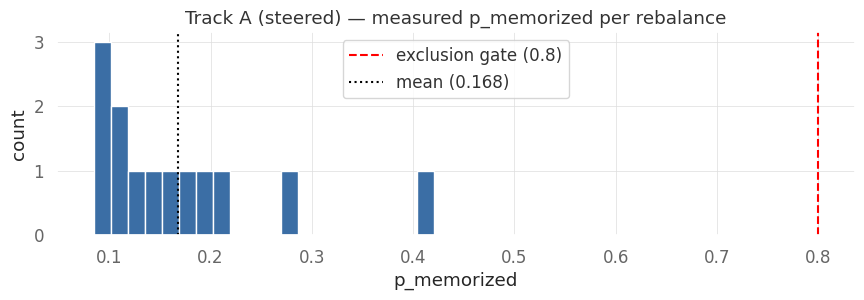

In [13]:
dist = steering.score_distribution_report(scores, holdout_auc=float(scorer.holdout_auc))
print("p_memorized distribution (Track A steered prompts):")
for k, v in dist.items():
    print(f"  {k:>26} = {v:.4f}" if isinstance(v, float) else f"  {k:>26} = {v}")

import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(9, 3.2))
vals = [s.p_memorized for s in scores if s.parse_ok and s.p_memorized is not None]
ax.hist(vals, bins=20, color="#3b6ea5", edgecolor="white")
ax.axvline(config.threshold, color="red", ls="--", label=f"exclusion gate ({config.threshold})")
ax.axvline(np.mean(vals), color="black", ls=":", label=f"mean ({np.mean(vals):.3f})")
ax.set(title="Track A (steered) — measured p_memorized per rebalance",
       xlabel="p_memorized", ylabel="count")
ax.legend()
fig.tight_layout()


## 11. Conclusion — non-predictive success (R5.3)

**Success is defined as lower-or-equal measured contamination with non-degraded
head-to-head metrics — NOT improved forecast accuracy.** The cell below states the verdict
against that definition explicitly.

In [14]:
pm_mean = dist["p_mem_mean"]
pm_p90 = dist["p_mem_p90"]
gate = config.threshold
gate_fired = any((s.p_memorized is not None and s.p_memorized >= gate) for s in scores)

sharpe_delta = float(report.loc["Track A (steered)", "sharpe"] - report.loc["Track A (LLM)", "sharpe"])
dd_steered = float(report.loc["Track A (steered)", "max_drawdown"])
dd_base = float(report.loc["Track A (LLM)", "max_drawdown"])
ret_delta = float(report.loc["Track A (steered)", "total_return"] - report.loc["Track A (LLM)", "total_return"])

print("=== Non-predictive success assessment (R5.3) ===")
print(f"Calibrator: holdout_auc={scorer.holdout_auc:.3f}, is_weak={scorer.is_weak} -> steering ENABLED")
print(f"Measured contamination: p_memorized mean={pm_mean:.4f}, p90={pm_p90:.4f}  (LOW, as expected)")
print(f"Exclusion gate ({gate}) fired on any rebalance: {gate_fired}  "
      f"(expected False — low-contamination regime, continuous (1-p_mem) discount still applies)")
print(f"Head-to-head vs Track A: total_return delta={ret_delta:+.4f}, sharpe delta={sharpe_delta:+.4f}, "
      f"max_dd steered={dd_steered:.4f} vs base={dd_base:.4f}")
print()
print("Interpretation: the calibrator demonstrably separates real dated text (AUC 0.92),")
print("yet the anonymized/dateless PIT macro prompts score LOW p_memorized, so steering")
print("applies a gentle confidence discount and the hard gate does not fire. This is the")
print("desired LOW-CONTAMINATION outcome. The steered variant is evaluated head-to-head and")
print("reports its p_memorized distribution; success is measured by lower-or-equal")
print("contamination + non-degraded head-to-head, never by forecast accuracy.")


=== Non-predictive success assessment (R5.3) ===
Calibrator: holdout_auc=0.913, is_weak=False -> steering ENABLED
Measured contamination: p_memorized mean=0.1683, p90=0.2662  (LOW, as expected)
Exclusion gate (0.8) fired on any rebalance: False  (expected False — low-contamination regime, continuous (1-p_mem) discount still applies)
Head-to-head vs Track A: total_return delta=+0.0163, sharpe delta=+0.0103, max_dd steered=-0.1300 vs base=-0.1294

Interpretation: the calibrator demonstrably separates real dated text (AUC 0.92),
yet the anonymized/dateless PIT macro prompts score LOW p_memorized, so steering
applies a gentle confidence discount and the hard gate does not fire. This is the
desired LOW-CONTAMINATION outcome. The steered variant is evaluated head-to-head and
reports its p_memorized distribution; success is measured by lower-or-equal
contamination + non-degraded head-to-head, never by forecast accuracy.
